In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from utils import load_data

sns.set_style("whitegrid")
sns.set_context("notebook")

plt.rcParams.update({
    'svg.fonttype': 'none',  # Export text as text not curves
    'font.size': 16, 
    "lines.linewidth": 2, 
    "axes.labelsize": 18,
    "axes.titlesize": 22
})

In [2]:
#parameters
db = "enamine_10k"
TITLE = "Enamine10k"

In [3]:
# Parameters
db = "mcl1_mmpbsa"
TITLE = "MCL1-MMPBSA"


In [4]:
db_batch = f"{db}_batch.sqlite"
db = f"{db}_shuffled.sqlite"
print(db, db_batch)

mcl1_mmpbsa_shuffled.sqlite mcl1_mmpbsa_batch.sqlite


In [5]:
if db.startswith("enamine_10k"):
    MOLS_PER_ITER = 100
elif db.startswith("enamine_50k"):
    MOLS_PER_ITER = 500
else:
    MOLS_PER_ITER = 600
MOLS_PER_ITER

600

In [6]:
OUTPUT_PREFIX = db.split(".")[0]

In [7]:
data_batch, top_k_batch, source = load_data(f"results/{db_batch}", k_ratio=0.01)
data, top_k, source = load_data(f"results/{db}", k_ratio=0.01)
assert (top_k_batch == top_k).all().all()
K = len(top_k)
data_batch["Surrogate"] = (data_batch["Surrogate"] + " (B)")
data_batch["Iteration"] *= MOLS_PER_ITER
data["Scenario"] = "Sequential"
data_batch["Scenario"] = "Batched"
data_batch["experiment_id"] = data_batch["experiment_id"] + data["experiment_id"].max()  # Start all from 0
df = pd.concat([data, data_batch], ignore_index=True)

In [8]:
HUE_ORDER=sorted(df["Surrogate"].unique())
HUE_ORDER

['Linear', 'Linear (B)']

/tmp/ipykernel_2238809/207230637.py:1: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  g = sns.pointplot(


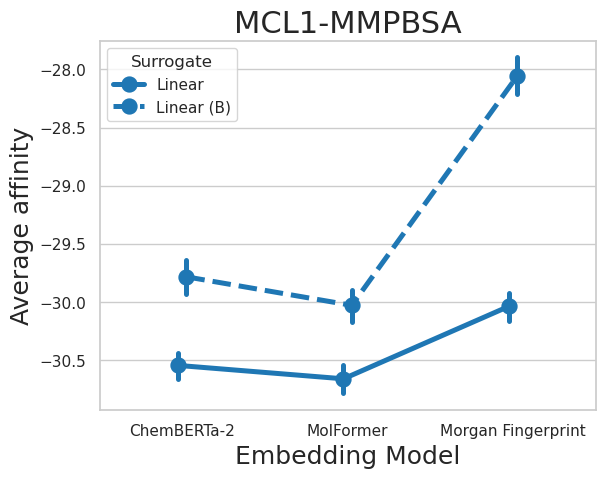

In [9]:
g = sns.pointplot(
    df,
    y="affinity",
    x="Embedding Model",
    hue="Surrogate",
    hue_order=HUE_ORDER,
    order=sorted(df["Embedding Model"].unique()),
    linestyles=["-", "--", "-", "--"],
    palette=["tab:blue", "tab:blue", "tab:orange", "tab:orange"],
    dodge=True
)
g.set_ylabel("Average affinity")
g.set_title(TITLE)
plt.savefig(f"figures/avg_affinity_{OUTPUT_PREFIX}.svg", format="svg")

In [10]:
tbl = df.groupby(["experiment_id", "Scenario", "Embedding Model", "Surrogate"])["is_top_k"].agg(lambda x: x.sum() / K)
tbl.reset_index().sort_values(by="Embedding Model")

,experiment_id,Scenario,Embedding Model,Surrogate,is_top_k
1,2,Sequential,ChemBERTa-2,Linear,0.541315
3,4,Batched,ChemBERTa-2,Linear (B),0.563238
2,3,Sequential,MolFormer,Linear,0.711636
5,6,Batched,MolFormer,Linear (B),0.600337
0,1,Sequential,Morgan Fingerprint,Linear,0.426644
4,5,Batched,Morgan Fingerprint,Linear (B),0.244519


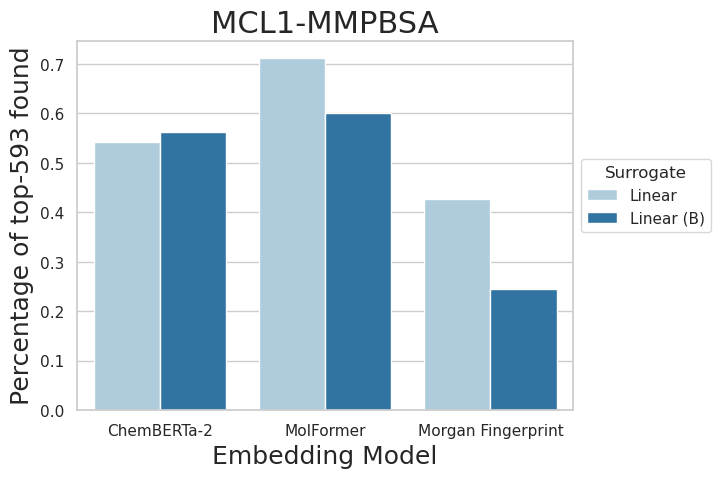

In [11]:
g = sns.barplot(
    df,
    y="is_top_k",
    x="Embedding Model",
    hue="Surrogate",
    hue_order=HUE_ORDER,
    errorbar=None,
    estimator = lambda x: x.sum() / K,
    order=sorted(df["Embedding Model"].unique()),
    dodge=True,
    palette="Paired", legend="brief"
)
g.set_ylabel(f"Percentage of top-{K} found")
g.set_title(TITLE)
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 0.7))
plt.savefig(f"figures/top_k_{OUTPUT_PREFIX}.svg", format="svg")

In [12]:
df[(df["Surrogate"] == "Linear" ) & (df["Scenario"] == "Sequential") & (df["Embedding Model"] == "ChemBERTa-2")]

,id,experiment_id,molecule,affinity,prediction_mean,prediction_std,acquisition_score,Iteration,cluster,output_file_path,...,n_clusters,simulator,bandit_confidence,job_id,Embedding Model,Surrogate,Scoring,is_top_k,is_top_k_cum,Scenario
3601,3602,2,CCc1cc(OC(=O)C[C@H](C)c2c[nH]c3ccccc23)ccc1Cl,-27.353764,inf,0.000000,1.055114,0,0,None,...,1,None,1.0,0,ChemBERTa-2,Linear,Expected Improvement,False,0,Sequential
3602,3603,2,COC(=O)c1[nH]c2ccccc2c1SC#N,-21.794066,-27.353764,1.618229,0.645580,1,0,None,...,1,None,1.0,0,ChemBERTa-2,Linear,Expected Improvement,False,0,Sequential
3603,3604,2,NC(=O)Cc1ccc(C(=O)COC(=O)c2[nH]c3c(Br)cccc3c2C...,-22.902161,-27.394003,0.077164,0.054997,2,0,None,...,1,None,1.0,0,ChemBERTa-2,Linear,Expected Improvement,False,0,Sequential
3604,3605,2,O=C(CCc1c(-c2ccc(F)cc2)[nH]c2c(Cl)cccc12)O[C@@...,-25.393695,-24.374824,2.235166,0.094877,3,0,None,...,1,None,1.0,0,ChemBERTa-2,Linear,Expected Improvement,False,0,Sequential
3605,3606,2,O=C(CCc1c(-c2ccc(F)cc2)[nH]c2ccc(F)cc12)O[C@@H...,-27.559379,-24.906997,1.828217,0.076677,4,0,None,...,1,None,1.0,0,ChemBERTa-2,Linear,Expected Improvement,False,0,Sequential
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7197,7198,2,O=C(CCc1c(-c2ccccc2)[nH]c2c(Cl)cccc12)Oc1c(Cl)...,-32.774199,-29.696143,3.528843,0.000012,3596,0,None,...,1,None,1.0,0,ChemBERTa-2,Linear,Expected Improvement,False,321,Sequential
7198,7199,2,O=C(CCc1c(-c2ccccc2)[nH]c2c(Cl)cccc12)Oc1cc(F)...,-32.330508,-29.753201,3.516379,0.000012,3597,0,None,...,1,None,1.0,0,ChemBERTa-2,Linear,Expected Improvement,False,321,Sequential
7199,7200,2,O=C(CCc1c(-c2ccccc2)[nH]c2c(Cl)cccc12)Oc1ccc(F...,-30.388893,-29.832419,3.503151,0.000012,3598,0,None,...,1,None,1.0,0,ChemBERTa-2,Linear,Expected Improvement,False,321,Sequential
7200,7201,2,O=C(CCc1c(-c2ccccc2)[nH]c2c(Cl)cccc12)Oc1ccc(F...,-33.194329,-29.829574,3.504017,0.000012,3599,0,None,...,1,None,1.0,0,ChemBERTa-2,Linear,Expected Improvement,False,321,Sequential


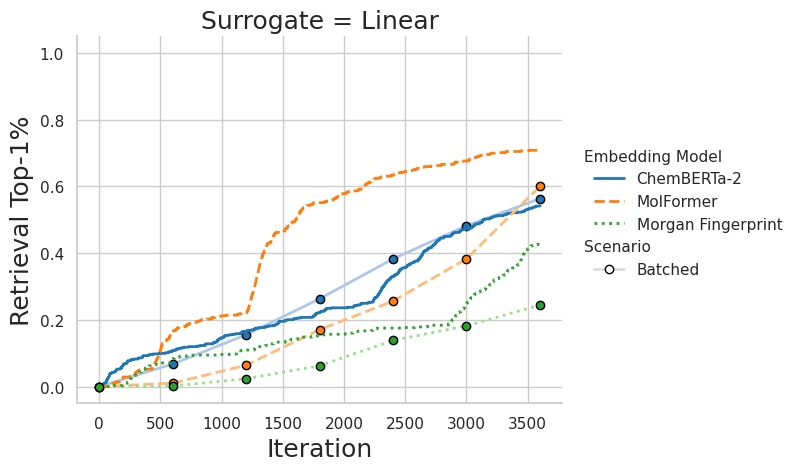

In [13]:
from utils import ProcessPlotter

df["Surrogate"] = df["Surrogate"].str.removesuffix(" (B)")
p = ProcessPlotter(df, len(top_k))
p.plot(col="Surrogate", col_order=["Linear"])

plt.savefig(f"figures/top_k_iter_{OUTPUT_PREFIX}.pdf", dpi=300, bbox_inches="tight")

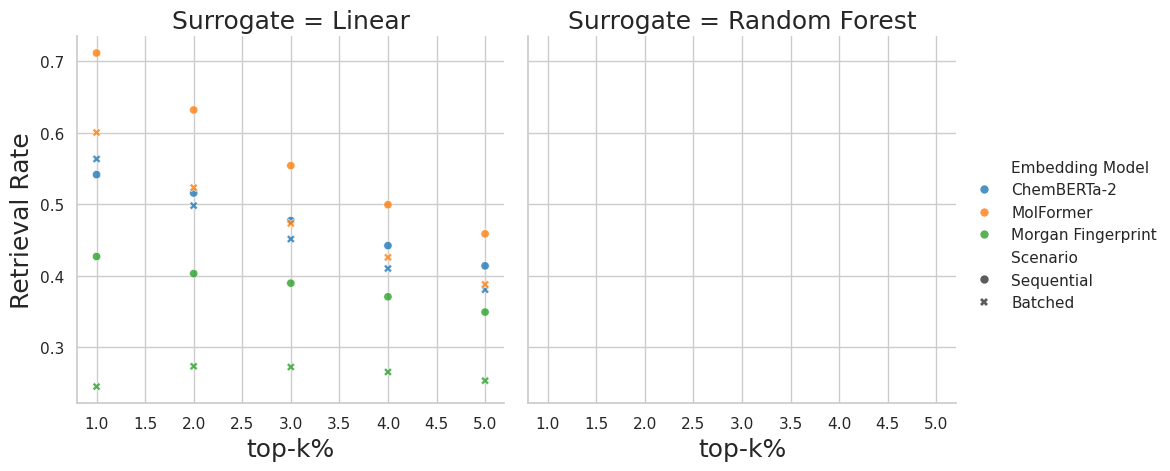

In [14]:
from math import floor
import pandas as pd

N_samples = data.groupby("experiment_id").size().unique()
assert len(N_samples) == 1
N_sampled = N_samples.item()

results = []
for ratio in range(1, 6):
    
    k = int(floor(len(source) * ratio / 100))
    top = source.sort_values(by="target")[:k]

    is_hit = df["molecule"].isin(top["smiles"])
    retrieval_rates = df[is_hit].groupby(["Embedding Model", "Surrogate", "Scenario"]).size() / k
    retrieval_rates = retrieval_rates.rename("Retrieval Rate")
    retrieval_rates = retrieval_rates.reset_index()

    retrieval_rates["top-k%"] = ratio
    retrieval_rates["num"] = k
    results.append(retrieval_rates)

retrieval_results = pd.concat(results)
sns.relplot(
    retrieval_results, x="top-k%", y="Retrieval Rate", hue="Embedding Model",
    hue_order=sorted(data["Embedding Model"].unique()),
    style="Scenario", 
    style_order=["Sequential", "Batched"],
    col="Surrogate", col_order=["Linear", "Random Forest"],
    alpha=0.8
    )